<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v2/notebooks/16_v2_evaluate_onpolicy_acceptance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers

In [2]:
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

TEST_DATA_PATH = (
    DRIVE_DIRECTORY
    / "test_teacher_states.pt"
)

ONE_STEP_CHECKPOINT_PATH = (
    DRIVE_DIRECTORY
    / "checkpoints"
    / "one_step_transition_seed42.pt"
)

MULTISTEP_CHECKPOINT_PATH = (
    DRIVE_DIRECTORY
    / "checkpoints"
    / "multistep_transition_seed42.pt"
)

print("Test data:", TEST_DATA_PATH.exists())
print(
    "One-step checkpoint:",
    ONE_STEP_CHECKPOINT_PATH.exists(),
)
print(
    "Multi-step checkpoint:",
    MULTISTEP_CHECKPOINT_PATH.exists(),
)

Test data: True
One-step checkpoint: True
Multi-step checkpoint: True


In [5]:
test_artifact = torch.load(
    TEST_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

test_token_ids = test_artifact[
    "token_ids"
]

MODEL_NAME = test_artifact[
    "model_name"
]

print("Model:", MODEL_NAME)
print("Test tokens:", test_token_ids.shape)

Model: distilgpt2
Test tokens: torch.Size([80, 64])


In [6]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

target_model = (
    AutoModelForCausalLM
    .from_pretrained(MODEL_NAME)
    .to(device)
)

target_model.eval()

for parameter in target_model.parameters():
    parameter.requires_grad = False

token_embedding = (
    target_model.get_input_embeddings()
)

print("Target model loaded.")
print(
    "Vocabulary size:",
    target_model.config.vocab_size,
)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Target model loaded.
Vocabulary size: 50257


In [7]:
class ResidualTransitionMLP(nn.Module):
    def __init__(
        self,
        hidden_dimension=768,
        bottleneck_dimension=512,
    ):
        super().__init__()

        combined_dimension = (
            hidden_dimension * 2
        )

        self.input_normalization = nn.LayerNorm(
            combined_dimension
        )

        self.network = nn.Sequential(
            nn.Linear(
                combined_dimension,
                bottleneck_dimension,
            ),
            nn.GELU(),
            nn.Linear(
                bottleneck_dimension,
                hidden_dimension,
            ),
        )

    def forward(
        self,
        current_hidden,
        next_token_embedding,
    ):
        combined_input = torch.cat(
            [
                current_hidden,
                next_token_embedding,
            ],
            dim=-1,
        )

        normalized_input = (
            self.input_normalization(
                combined_input
            )
        )

        predicted_change = self.network(
            normalized_input
        )

        return (
            current_hidden
            + predicted_change
        )

In [8]:
def load_transition_model(
    checkpoint_path,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    model = ResidualTransitionMLP(
        hidden_dimension=checkpoint[
            "hidden_dimension"
        ],
        bottleneck_dimension=checkpoint[
            "bottleneck_dimension"
        ],
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model = model.to(device)
    model.eval()

    return model, checkpoint

In [9]:
(
    one_step_model,
    one_step_checkpoint,
) = load_transition_model(
    ONE_STEP_CHECKPOINT_PATH
)

(
    multistep_model,
    multistep_checkpoint,
) = load_transition_model(
    MULTISTEP_CHECKPOINT_PATH
)

print("Both transition models loaded.")

Both transition models loaded.


In [10]:
PREFIX_LENGTH = 32
PROMPT_INDEX = 0

prefix_ids = (
    test_token_ids[
        PROMPT_INDEX,
        :PREFIX_LENGTH,
    ]
    .unsqueeze(0)
    .to(device)
)

print("Prefix shape:", prefix_ids.shape)

print("\nDecoded prefix:\n")
print(
    tokenizer.decode(
        prefix_ids[0]
    )
)

Prefix shape: torch.Size([1, 32])

Decoded prefix:

= Robert Boulter =<|endoftext|>Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the


In [11]:
with torch.no_grad():
    prefix_outputs = target_model(
        input_ids=prefix_ids,
        output_hidden_states=True,
        return_dict=True,
    )

true_prefix_hidden = (
    prefix_outputs.hidden_states[-1][
        :,
        -1,
        :,
    ]
)

target_first_logits = (
    prefix_outputs.logits[
        :,
        -1,
        :,
    ]
)

direct_head_logits = (
    target_model.lm_head(
        true_prefix_hidden
    )
)

maximum_logit_difference = (
    torch.max(
        torch.abs(
            target_first_logits
            - direct_head_logits
        )
    )
    .item()
)

print(
    "Maximum logit difference:",
    maximum_logit_difference,
)

Maximum logit difference: 5.340576171875e-05


In [12]:
def logits_to_probabilities(logits):
    return torch.softmax(
        logits,
        dim=-1,
    )

In [13]:
q1 = logits_to_probabilities(
    direct_head_logits
)

torch.manual_seed(SEED)

draft_token_1 = torch.multinomial(
    q1,
    num_samples=1,
)

print(
    "Draft token 1 ID:",
    draft_token_1.item(),
)

print(
    "Draft token 1 text:",
    repr(
        tokenizer.decode(
            draft_token_1[0]
        )
    ),
)

Draft token 1 ID: 2277
Draft token 1 text: ' hit'


In [14]:
with torch.no_grad():
    token_1_embedding = token_embedding(
        draft_token_1
    ).squeeze(1)

    predicted_hidden_1 = (
        multistep_model(
            true_prefix_hidden,
            token_1_embedding,
        )
    )

    predicted_logits_2 = (
        target_model.lm_head(
            predicted_hidden_1
        )
    )

    q2 = logits_to_probabilities(
        predicted_logits_2
    )

In [15]:
draft_token_2 = torch.multinomial(
    q2,
    num_samples=1,
)

print(
    "Draft token 2 ID:",
    draft_token_2.item(),
)

print(
    "Draft token 2 text:",
    repr(
        tokenizer.decode(
            draft_token_2[0]
        )
    ),
)

Draft token 2 ID: 262
Draft token 2 text: ' the'


In [16]:
verification_input = torch.cat(
    [
        prefix_ids,
        draft_token_1,
    ],
    dim=1,
)

with torch.no_grad():
    verification_outputs = target_model(
        input_ids=verification_input,
        return_dict=True,
    )

target_logits_2 = (
    verification_outputs.logits[
        :,
        -1,
        :,
    ]
)

p2 = logits_to_probabilities(
    target_logits_2
)

print(
    "Verification input length:",
    verification_input.shape[1],
)

Verification input length: 33


In [17]:
log_p2 = torch.log(
    p2.clamp_min(1e-12)
)

log_q2 = torch.log(
    q2.clamp_min(1e-12)
)

output_kl_step_2 = torch.sum(
    p2 * (log_p2 - log_q2),
    dim=-1,
)

print(
    "Step-2 output KL:",
    output_kl_step_2.item(),
)

Step-2 output KL: 1.4036126136779785


In [18]:
draft_token_2_probability_under_p = (
    p2.gather(
        dim=1,
        index=draft_token_2,
    )
    .squeeze()
)

draft_token_2_probability_under_q = (
    q2.gather(
        dim=1,
        index=draft_token_2,
    )
    .squeeze()
)

acceptance_probability_step_2 = (
    torch.minimum(
        torch.ones(
            (),
            device=device,
        ),
        (
            draft_token_2_probability_under_p
            / draft_token_2_probability_under_q
              .clamp_min(1e-12)
        ),
    )
)

print(
    "p(draft token 2):",
    draft_token_2_probability_under_p.item(),
)

print(
    "q(draft token 2):",
    draft_token_2_probability_under_q.item(),
)

print(
    "Step-2 acceptance probability:",
    acceptance_probability_step_2.item(),
)

p(draft token 2): 0.0003640451468527317
q(draft token 2): 0.04324853792786598
Step-2 acceptance probability: 0.008417513221502304


In [19]:
uniform_random_value = torch.rand(
    (),
    device=device,
)

accepted_step_2 = (
    uniform_random_value
    < acceptance_probability_step_2
)

print(
    "Uniform random value:",
    uniform_random_value.item(),
)

print(
    "Accepted step 2:",
    accepted_step_2.item(),
)

Uniform random value: 0.8258668184280396
Accepted step 2: False


In [20]:
def compute_step_2_kl(
    transition_model,
):
    with torch.no_grad():
        predicted_hidden = (
            transition_model(
                true_prefix_hidden,
                token_1_embedding,
            )
        )

        predicted_logits = (
            target_model.lm_head(
                predicted_hidden
            )
        )

        predicted_probabilities = (
            torch.softmax(
                predicted_logits,
                dim=-1,
            )
        )

        predicted_log_probabilities = (
            torch.log(
                predicted_probabilities
                .clamp_min(1e-12)
            )
        )

        kl = torch.sum(
            p2
            * (
                log_p2
                - predicted_log_probabilities
            ),
            dim=-1,
        )

    return kl.item()

In [21]:
one_step_kl = compute_step_2_kl(
    one_step_model
)

multistep_kl = compute_step_2_kl(
    multistep_model
)

print("One-step model KL:", one_step_kl)
print("Multi-step model KL:", multistep_kl)

One-step model KL: 1.5834081172943115
Multi-step model KL: 1.4036126136779785


In [22]:
MAX_GAMMA = 16
GAMMAS = [2, 4, 8, 16]

NUMBER_OF_PROMPTS = 80
NUMBER_OF_TRIALS = 3

PREFIX_LENGTH = 32

print("Maximum gamma:", MAX_GAMMA)
print("Gammas:", GAMMAS)
print("Prompts:", NUMBER_OF_PROMPTS)
print("Trials per prompt:", NUMBER_OF_TRIALS)

Maximum gamma: 16
Gammas: [2, 4, 8, 16]
Prompts: 80
Trials per prompt: 3


In [23]:
prefix_cache = {}

for prompt_index in range(
    NUMBER_OF_PROMPTS
):
    prefix_ids = (
        test_token_ids[
            prompt_index,
            :PREFIX_LENGTH,
        ]
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():
        outputs = target_model(
            input_ids=prefix_ids,
            output_hidden_states=True,
            return_dict=True,
        )

    prefix_hidden = (
        outputs.hidden_states[-1][
            :,
            -1,
            :,
        ]
    )

    prefix_logits = (
        outputs.logits[
            :,
            -1,
            :,
        ]
    )

    prefix_cache[prompt_index] = {
        "input_ids": prefix_ids,
        "hidden": prefix_hidden,
        "logits": prefix_logits,
    }

    if (
        prompt_index == 0
        or (prompt_index + 1) % 20 == 0
    ):
        print(
            "Cached prefixes:",
            prompt_index + 1,
            "/",
            NUMBER_OF_PROMPTS,
        )

Cached prefixes: 1 / 80
Cached prefixes: 20 / 80
Cached prefixes: 40 / 80
Cached prefixes: 60 / 80
Cached prefixes: 80 / 80


In [24]:
def generate_draft_chain(
    transition_model,
    prefix_hidden,
    maximum_gamma,
    sampling_seed,
):
    """
    Generate a complete latent draft chain.

    Returns:
        draft_tokens: [1, gamma]
        q_probabilities: [1, gamma, vocabulary]
        predicted_states: [1, gamma, hidden_dimension]

    predicted_states[:, i] is the state used to
    predict draft token i.
    """

    torch.manual_seed(sampling_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            sampling_seed
        )

    current_hidden = prefix_hidden

    draft_token_list = []
    q_probability_list = []
    predicted_state_list = []

    with torch.no_grad():
        for position in range(
            maximum_gamma
        ):
            predicted_state_list.append(
                current_hidden.detach()
            )

            logits = target_model.lm_head(
                current_hidden
            )

            q_probabilities = torch.softmax(
                logits,
                dim=-1,
            )

            draft_token = torch.multinomial(
                q_probabilities,
                num_samples=1,
            )

            q_probability_list.append(
                q_probabilities.detach()
            )

            draft_token_list.append(
                draft_token
            )

            next_embedding = (
                token_embedding(
                    draft_token
                )
                .squeeze(1)
            )

            current_hidden = (
                transition_model(
                    current_hidden,
                    next_embedding,
                )
            )

    draft_tokens = torch.cat(
        draft_token_list,
        dim=1,
    )

    q_probability_tensor = torch.stack(
        q_probability_list,
        dim=1,
    )

    predicted_state_tensor = torch.stack(
        predicted_state_list,
        dim=1,
    )

    return (
        draft_tokens,
        q_probability_tensor,
        predicted_state_tensor,
    )

In [25]:
def verify_draft_chain(
    prefix_ids,
    draft_tokens,
):
    """
    Compute target distributions for every draft
    position in one target forward pass.
    """

    verification_input = torch.cat(
        [
            prefix_ids,
            draft_tokens,
        ],
        dim=1,
    )

    prefix_length = prefix_ids.shape[1]
    draft_length = draft_tokens.shape[1]

    with torch.no_grad():
        outputs = target_model(
            input_ids=verification_input,
            output_hidden_states=True,
            return_dict=True,
        )

    # Position prefix_length - 1 predicts draft token 1.
    start_index = prefix_length - 1
    end_index = (
        start_index + draft_length
    )

    target_logits = outputs.logits[
        :,
        start_index:end_index,
        :,
    ]

    target_states = (
        outputs.hidden_states[-1][
            :,
            start_index:end_index,
            :,
        ]
    )

    p_probabilities = torch.softmax(
        target_logits,
        dim=-1,
    )

    return (
        p_probabilities,
        target_states,
    )

In [26]:
def compute_chain_metrics(
    draft_tokens,
    q_probabilities,
    predicted_states,
    p_probabilities,
    target_states,
    uniform_random_values,
):
    """
    Compute metrics at every draft position.
    """

    p_log = torch.log(
        p_probabilities.clamp_min(
            1e-12
        )
    )

    q_log = torch.log(
        q_probabilities.clamp_min(
            1e-12
        )
    )

    output_kl = torch.sum(
        p_probabilities
        * (p_log - q_log),
        dim=-1,
    ).squeeze(0)

    selected_p = (
        p_probabilities.gather(
            dim=2,
            index=draft_tokens
            .unsqueeze(-1),
        )
        .squeeze(0)
        .squeeze(-1)
    )

    selected_q = (
        q_probabilities.gather(
            dim=2,
            index=draft_tokens
            .unsqueeze(-1),
        )
        .squeeze(0)
        .squeeze(-1)
    )

    acceptance_probability = (
        torch.minimum(
            torch.ones_like(selected_p),
            selected_p
            / selected_q.clamp_min(
                1e-12
            ),
        )
    )

    would_accept = (
        uniform_random_values.to(device)
        < acceptance_probability
    )

    predicted_states_flat = (
        predicted_states.squeeze(0)
    )

    target_states_flat = (
        target_states.squeeze(0)
    )

    difference_norm = (
        torch.linalg.vector_norm(
            predicted_states_flat
            - target_states_flat,
            dim=-1,
        )
    )

    target_norm = (
        torch.linalg.vector_norm(
            target_states_flat,
            dim=-1,
        )
    )

    normalized_l2 = (
        difference_norm
        / (target_norm + 1e-8)
    )

    cosine_similarity = (
        F.cosine_similarity(
            predicted_states_flat,
            target_states_flat,
            dim=-1,
        )
    )

    entropy = -torch.sum(
        q_probabilities.squeeze(0)
        * q_log.squeeze(0),
        dim=-1,
    )

    top_two_probabilities = torch.topk(
        q_probabilities.squeeze(0),
        k=2,
        dim=-1,
    ).values

    top1_margin = (
        top_two_probabilities[:, 0]
        - top_two_probabilities[:, 1]
    )

    return {
        "output_kl": output_kl,
        "acceptance_probability": (
            acceptance_probability
        ),
        "would_accept": would_accept,
        "normalized_l2": normalized_l2,
        "cosine_similarity": (
            cosine_similarity
        ),
        "entropy": entropy,
        "top1_margin": top1_margin,
        "selected_p": selected_p,
        "selected_q": selected_q,
    }

In [27]:
def accepted_prefix_length(
    would_accept,
    gamma,
):
    accepted_count = 0

    for position in range(gamma):
        if would_accept[position].item():
            accepted_count += 1
        else:
            break

    return accepted_count

In [28]:
ONPOLICY_CHECKPOINT_PATH = (
    DRIVE_DIRECTORY
    / "checkpoints_v2"
    / "onpolicy_latent_transition_seed42.pt"
)

print(
    "On-policy checkpoint exists:",
    ONPOLICY_CHECKPOINT_PATH.exists(),
)

On-policy checkpoint exists: True


In [29]:
(
    onpolicy_model,
    onpolicy_checkpoint,
) = load_transition_model(
    ONPOLICY_CHECKPOINT_PATH
)

print(
    "On-policy checkpoint loaded."
)

print(
    "Best validation loss:",
    onpolicy_checkpoint[
        "best_validation_loss"
    ],
)

On-policy checkpoint loaded.
Best validation loss: 0.13533176183700563


In [30]:
import pandas as pd
import time

method_models = {
    "One-step": one_step_model,
    "Multi-step": multistep_model,
    "On-policy latent": onpolicy_model,
}

position_rows = []
round_rows = []

experiment_start_time = time.time()

for prompt_index in range(
    NUMBER_OF_PROMPTS
):
    prefix_information = (
        prefix_cache[prompt_index]
    )

    prefix_ids = prefix_information[
        "input_ids"
    ]

    prefix_hidden = prefix_information[
        "hidden"
    ]

    for trial_index in range(
        NUMBER_OF_TRIALS
    ):
        # 两个模型使用同一组基础随机种子
        sampling_seed = (
            SEED
            + prompt_index * 100
            + trial_index
        )

        uniform_generator = (
            torch.Generator(
                device="cpu"
            )
        )

        uniform_generator.manual_seed(
            sampling_seed + 1_000_000
        )

        uniform_random_values = torch.rand(
            MAX_GAMMA,
            generator=uniform_generator,
        )

        for (
            method_name,
            transition_model,
        ) in method_models.items():

            (
                draft_tokens,
                q_probabilities,
                predicted_states,
            ) = generate_draft_chain(
                transition_model=(
                    transition_model
                ),
                prefix_hidden=(
                    prefix_hidden
                ),
                maximum_gamma=MAX_GAMMA,
                sampling_seed=sampling_seed,
            )

            (
                p_probabilities,
                target_states,
            ) = verify_draft_chain(
                prefix_ids=prefix_ids,
                draft_tokens=draft_tokens,
            )

            chain_metrics = (
                compute_chain_metrics(
                    draft_tokens=(
                        draft_tokens
                    ),
                    q_probabilities=(
                        q_probabilities
                    ),
                    predicted_states=(
                        predicted_states
                    ),
                    p_probabilities=(
                        p_probabilities
                    ),
                    target_states=(
                        target_states
                    ),
                    uniform_random_values=(
                        uniform_random_values
                    ),
                )
            )

            for position in range(
                MAX_GAMMA
            ):
                position_rows.append({
                    "method": method_name,
                    "prompt_index": (
                        prompt_index
                    ),
                    "trial_index": (
                        trial_index
                    ),
                    "position": position + 1,
                    "output_kl": (
                        chain_metrics[
                            "output_kl"
                        ][position].item()
                    ),
                    "acceptance_probability": (
                        chain_metrics[
                            "acceptance_probability"
                        ][position].item()
                    ),
                    "would_accept": int(
                        chain_metrics[
                            "would_accept"
                        ][position].item()
                    ),
                    "normalized_l2": (
                        chain_metrics[
                            "normalized_l2"
                        ][position].item()
                    ),
                    "cosine_similarity": (
                        chain_metrics[
                            "cosine_similarity"
                        ][position].item()
                    ),
                    "entropy": (
                        chain_metrics[
                            "entropy"
                        ][position].item()
                    ),
                    "top1_margin": (
                        chain_metrics[
                            "top1_margin"
                        ][position].item()
                    ),
                    "selected_p": (
                        chain_metrics[
                            "selected_p"
                        ][position].item()
                    ),
                    "selected_q": (
                        chain_metrics[
                            "selected_q"
                        ][position].item()
                    ),
                    "draft_token_id": (
                        draft_tokens[
                            0,
                            position,
                        ].item()
                    ),
                })

            for gamma in GAMMAS:
                accepted_count = (
                    accepted_prefix_length(
                        chain_metrics[
                            "would_accept"
                        ],
                        gamma,
                    )
                )

                accepted_beyond_first = max(
                    accepted_count - 1,
                    0,
                )

                round_rows.append({
                    "method": method_name,
                    "prompt_index": (
                        prompt_index
                    ),
                    "trial_index": (
                        trial_index
                    ),
                    "gamma": gamma,
                    "accepted_prefix_length": (
                        accepted_count
                    ),
                    "accepted_beyond_first": (
                        accepted_beyond_first
                    ),
                    "acceptance_rate_pos2plus": (
                        accepted_beyond_first
                        / max(gamma - 1, 1)
                    ),
                    "all_draft_tokens_accepted": int(
                        accepted_count == gamma
                    ),
                })

    if (
        prompt_index == 0
        or (prompt_index + 1) % 10 == 0
    ):
        elapsed = (
            time.time()
            - experiment_start_time
        )

        print(
            f"Completed "
            f"{prompt_index + 1}/"
            f"{NUMBER_OF_PROMPTS} prompts "
            f"in {elapsed:.1f} seconds"
        )

Completed 1/80 prompts in 0.4 seconds
Completed 10/80 prompts in 2.0 seconds
Completed 20/80 prompts in 3.7 seconds
Completed 30/80 prompts in 5.5 seconds
Completed 40/80 prompts in 7.4 seconds
Completed 50/80 prompts in 9.5 seconds
Completed 60/80 prompts in 11.4 seconds
Completed 70/80 prompts in 13.1 seconds
Completed 80/80 prompts in 16.6 seconds


In [31]:
position_df = pd.DataFrame(
    position_rows
)

round_df = pd.DataFrame(
    round_rows
)

print("Position rows:", len(position_df))
print("Round rows:", len(round_df))

Position rows: 11520
Round rows: 2880


In [32]:
position_one_summary = (
    position_df[
        position_df["position"] == 1
    ]
    .groupby("method")
    .agg(
        mean_kl=(
            "output_kl",
            "mean",
        ),
        mean_acceptance_probability=(
            "acceptance_probability",
            "mean",
        ),
        empirical_acceptance=(
            "would_accept",
            "mean",
        ),
    )
    .reset_index()
)

print(
    position_one_summary.to_string(
        index=False
    )
)

          method       mean_kl  mean_acceptance_probability  empirical_acceptance
      Multi-step -1.023788e-08                     0.999992                   1.0
On-policy latent -1.023788e-08                     0.999992                   1.0
        One-step -1.023788e-08                     0.999992                   1.0


In [33]:
position_summary_df = (
    position_df
    .groupby(
        [
            "method",
            "position",
        ],
        as_index=False,
    )
    .agg(
        mean_output_kl=(
            "output_kl",
            "mean",
        ),
        mean_acceptance_probability=(
            "acceptance_probability",
            "mean",
        ),
        empirical_acceptance=(
            "would_accept",
            "mean",
        ),
        mean_normalized_l2=(
            "normalized_l2",
            "mean",
        ),
        mean_cosine_similarity=(
            "cosine_similarity",
            "mean",
        ),
        mean_entropy=(
            "entropy",
            "mean",
        ),
    )
)

print(
    position_summary_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        ),
    )
)

          method  position  mean_output_kl  mean_acceptance_probability  empirical_acceptance  mean_normalized_l2  mean_cosine_similarity  mean_entropy
      Multi-step         1         -0.0000                       1.0000                1.0000              0.0000                  1.0000        4.5045
      Multi-step         2          1.5477                       0.4285                0.4042              0.2468                  0.9639        5.5890
      Multi-step         3          2.2714                       0.3146                0.2833              0.2318                  0.9669        6.0231
      Multi-step         4          2.1623                       0.3530                0.3625              0.2284                  0.9718        5.9576
      Multi-step         5          2.0687                       0.3963                0.3875              0.2006                  0.9751        6.1694
      Multi-step         6          2.2087                       0.3570                0

In [34]:
round_summary_df = (
    round_df
    .groupby(
        [
            "method",
            "gamma",
        ],
        as_index=False,
    )
    .agg(
        mean_accepted_prefix=(
            "accepted_prefix_length",
            "mean",
        ),
        mean_accepted_beyond_first=(
            "accepted_beyond_first",
            "mean",
        ),
        acceptance_rate_pos2plus=(
            "acceptance_rate_pos2plus",
            "mean",
        ),
        full_acceptance_rate=(
            "all_draft_tokens_accepted",
            "mean",
        ),
    )
)

print(
    round_summary_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        ),
    )
)

          method  gamma  mean_accepted_prefix  mean_accepted_beyond_first  acceptance_rate_pos2plus  full_acceptance_rate
      Multi-step      2                1.4042                      0.4042                    0.4042                0.4042
      Multi-step      4                1.5458                      0.5458                    0.1819                0.0458
      Multi-step      8                1.5625                      0.5625                    0.0804                0.0000
      Multi-step     16                1.5625                      0.5625                    0.0375                0.0000
On-policy latent      2                1.4042                      0.4042                    0.4042                0.4042
On-policy latent      4                1.5542                      0.5542                    0.1847                0.0417
On-policy latent      8                1.5833                      0.5833                    0.0833                0.0000
On-policy latent     16 

In [35]:
overall_onpolicy_df = (
    position_df[
        position_df["position"] > 1
    ]
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        mean_output_kl=(
            "output_kl",
            "mean",
        ),
        mean_acceptance_probability=(
            "acceptance_probability",
            "mean",
        ),
        empirical_acceptance=(
            "would_accept",
            "mean",
        ),
        mean_normalized_l2=(
            "normalized_l2",
            "mean",
        ),
    )
)

print(
    overall_onpolicy_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        ),
    )
)

          method  mean_output_kl  mean_acceptance_probability  empirical_acceptance  mean_normalized_l2
      Multi-step          2.1037                       0.3741                0.3750              0.2144
On-policy latent          2.0465                       0.3757                0.3761              0.2107
        One-step          2.2090                       0.3650                0.3658              0.2241


In [36]:
method_order = [
    "One-step",
    "Multi-step",
    "On-policy latent",
]

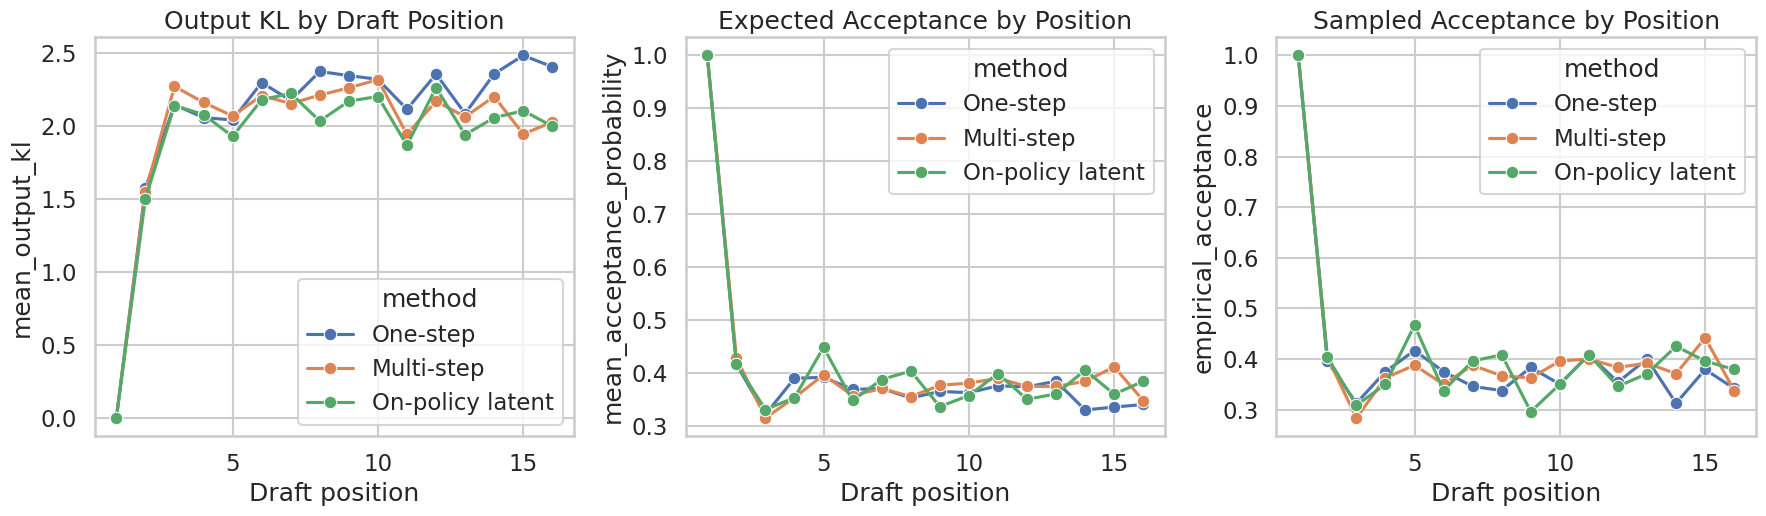

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk",
)

position_figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
)

sns.lineplot(
    data=position_summary_df,
    x="position",
    y="mean_output_kl",
    hue="method",
    hue_order=method_order,
    marker="o",
    ax=axes[0],
)

axes[0].set_title(
    "Output KL by Draft Position"
)

sns.lineplot(
    data=position_summary_df,
    x="position",
    y="mean_acceptance_probability",
    hue="method",
    hue_order=method_order,
    marker="o",
    ax=axes[1],
)

axes[1].set_title(
    "Expected Acceptance by Position"
)

sns.lineplot(
    data=position_summary_df,
    x="position",
    y="empirical_acceptance",
    hue="method",
    hue_order=method_order,
    marker="o",
    ax=axes[2],
)

axes[2].set_title(
    "Sampled Acceptance by Position"
)

for axis in axes:
    axis.set_xlabel("Draft position")

position_figure.tight_layout()
plt.show()

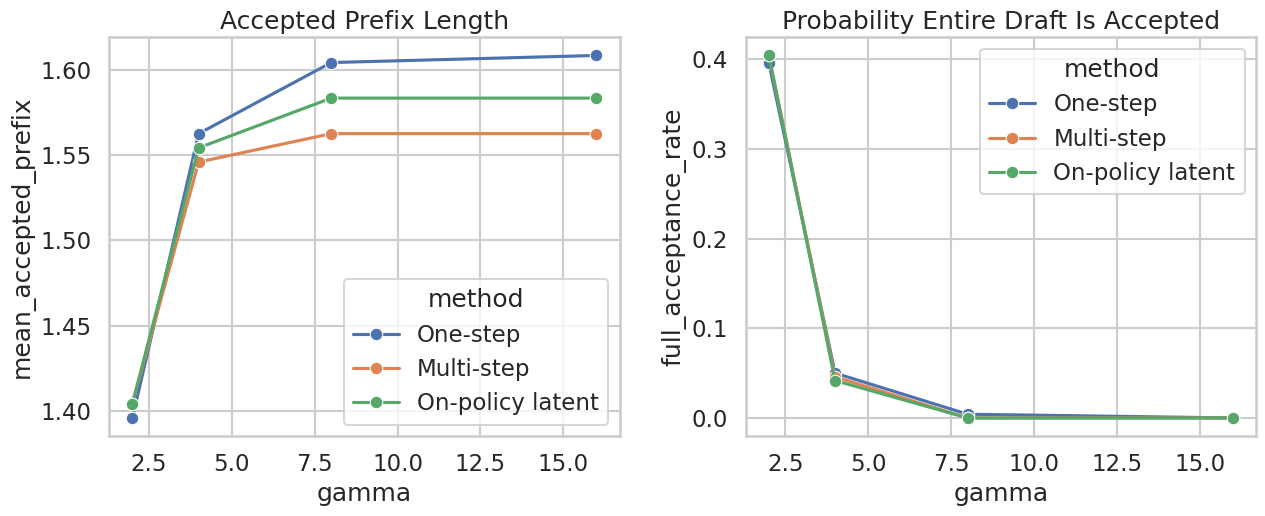

In [39]:
gamma_figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
)

sns.lineplot(
    data=round_summary_df,
    x="gamma",
    y="mean_accepted_prefix",
    hue="method",
    hue_order=method_order,
    marker="o",
    ax=axes[0],
)

axes[0].set_title(
    "Accepted Prefix Length"
)

sns.lineplot(
    data=round_summary_df,
    x="gamma",
    y="full_acceptance_rate",
    hue="method",
    hue_order=method_order,
    marker="o",
    ax=axes[1],
)

axes[1].set_title(
    "Probability Entire Draft Is Accepted"
)

gamma_figure.tight_layout()
plt.show()

In [41]:
V2_RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results_v2"
)

V2_TABLE_DIRECTORY = (
    V2_RESULT_DIRECTORY
    / "tables"
)

V2_FIGURE_DIRECTORY = (
    V2_RESULT_DIRECTORY
    / "figures"
)

V2_TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

V2_FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

In [42]:
position_df.to_csv(
    V2_TABLE_DIRECTORY
    / "three_model_position_samples.csv",
    index=False,
)

round_df.to_csv(
    V2_TABLE_DIRECTORY
    / "three_model_gamma_samples.csv",
    index=False,
)

position_summary_df.to_csv(
    V2_TABLE_DIRECTORY
    / "three_model_position_summary.csv",
    index=False,
)

round_summary_df.to_csv(
    V2_TABLE_DIRECTORY
    / "three_model_gamma_summary.csv",
    index=False,
)

overall_onpolicy_df.to_csv(
    V2_TABLE_DIRECTORY
    / "three_model_overall_summary.csv",
    index=False,
)

position_figure.savefig(
    V2_FIGURE_DIRECTORY
    / "three_model_acceptance_by_position.png",
    dpi=250,
    bbox_inches="tight",
)

gamma_figure.savefig(
    V2_FIGURE_DIRECTORY
    / "three_model_fixed_gamma.png",
    dpi=250,
    bbox_inches="tight",
)

print("Three-model results saved.")

Three-model results saved.
